# Projet Deep Learning : Intel Image Classification
## Notebook Final

Ce notebook présente une approche de bout en bout pour classifier des images de paysages naturels (`Intel Image Classification`). Il est configuré pour s'exécuter sur **Google Colab** en récupérant les données directement depuis la dataset dans **Google Drive**.

### Structure du projet :
1. **Connexion au Google Drive** et configuration des chemins d'accès.
2. **Pipeline de données complet** (chargement, normalisation ImageNet, augmentation de données).
3. **Abstraction PyTorch Lightning** pour un code propre, modulaire et reproductible.
4. **Comparaison d'architectures** : Un `SimpleCNN` (conçu de zéro) vs. `ResNet18` (Transfer Learning).
5. **Suivi des métriques & Entraînement** (Early Stopping, Learning Rate Scheduler).
6. **Interprétation avancée des résultats** (Matrice de confusion, rapport de classification, courbes ROC et cartes d'activation).

In [52]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 0 — Installations, Imports et Connexion Google Drive

In [53]:
# Installation des dépendances requises dans l'environnement Colab
!pip install -q torch torchvision torchmetrics pytorch_lightning scikit-learn seaborn matplotlib

In [54]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

import torchmetrics
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from torchvision import transforms, models

# Fixer le seed pour assurer la reproductibilité complète des expériences
SEED = 42
pl.seed_everything(SEED)

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

print("Environnement initialisé avec succès ✓")

INFO:lightning_fabric.utilities.seed:Seed set to 42


Environnement initialisé avec succès ✓


In [55]:
# Montage du Google Drive
from google.colab import drive
import os
drive.mount('/content/drive')

# Configuration absolue basée rigoureusement sur votre capture d'écran
BASE_DATA_DIR = "/content/drive/MyDrive/deep_learning/image_dataset"

# En ajoutant manuellement le sous-dossier d'extraction Kaggle
DATA_DIR_TRAIN = os.path.join(BASE_DATA_DIR, "seg_train", "seg_train")
DATA_DIR_TEST = os.path.join(BASE_DATA_DIR, "seg_test", "seg_test")

# SÉCURITÉ : Cette ligne va vous afficher le nombre de classes trouvées
try:
    print("✓ Dossier Train trouvé ! Classes :", sorted(os.listdir(DATA_DIR_TRAIN)))
    print("✓ Dossier Test trouvé ! Classes :", sorted(os.listdir(DATA_DIR_TEST)))
except FileNotFoundError:
    print("⚠️ Le sous-dossier doublé n'existe pas. Tentative avec le dossier simple...")
    DATA_DIR_TRAIN = os.path.join(BASE_DATA_DIR, "seg_train")
    DATA_DIR_TEST = os.path.join(BASE_DATA_DIR, "seg_test")
    print("✓ Classes Train :", sorted(os.listdir(DATA_DIR_TRAIN)))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Dossier Train trouvé ! Classes : ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
✓ Dossier Test trouvé ! Classes : ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


## 1 — Pipeline Deep Learning (Data & Augmentation)

Pour contrer le surapprentissage, nous mettons en place des transformations d'augmentation de données sur le jeu d'entraînement (rotations, retournements, légères modifications de contraste). Les images sont redimensionnées au format standard attendu ($150\times150$ px).

In [56]:
IMG_SIZE = 150

# Augmentation pour l'entraînement & Normalisation standard ImageNet
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Pas d'augmentation pour le test (uniquement mise à l'échelle et normalisation)
val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class IntelImageDataset(Dataset):
    """Dataset personnalisé pour parser l'arborescence native des données Intel"""
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []

        self.class_names = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.class_names)}

        for cls_name in self.class_names:
            cls_dir = os.path.join(root_dir, cls_name)
            if os.path.isdir(cls_dir):
                for img_name in os.listdir(cls_dir):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                        self.image_paths.append(os.path.join(cls_dir, img_name))
                        self.labels.append(self.class_to_idx[cls_name])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

## 2 — Abstraction avec PyTorch Lightning

Nous encapsulons le cycle de vie du modèle dans un `LightningModule` pour simplifier les boucles d'entraînement et d'évaluation, tout en intégrant des métriques d'exactitude globales.

In [57]:
class LitIntelClassifier(pl.LightningModule):
    def __init__(self, model_architecture, num_classes=6, lr=1e-3, weight_decay=1e-4):
        super().__init__()
        self.save_hyperparameters(ignore=['model_architecture'])
        self.model = model_architecture
        self.criterion = nn.CrossEntropyLoss()

        # Utilisation de TorchMetrics pour le suivi
        self.train_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.val_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.test_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = self.train_acc(logits, y)

        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('train_acc', acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = self.val_acc(logits, y)

        self.log('val_loss', loss, on_epoch=True, prog_bar=True)
        self.log('val_acc', acc, on_epoch=True, prog_bar=True)

    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = self.test_acc(logits, y)

        self.log('test_loss', loss, on_epoch=True)
        self.log('test_acc', acc, on_epoch=True)
        return {"logits": logits, "labels": y}

    def configure_optimizers(self):
        optimizer = optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.weight_decay)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
        return {
            "optimizer": optimizer,
            "lr_scheduler": {"scheduler": scheduler, "monitor": "val_loss"}
        }

## 3 — Définition des Deux Architectures à Comparer

Nous confrontons ici deux approches techniques :
- **Modèle Baseline** : Un `SimpleCNN` monté à la main (3 blocs de convolution avec `BatchNorm` et `Dropout`).
- **Modèle Avancé (Transfer Learning)** : Une architecture `ResNet18` pré-entraînée.

In [58]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

class ResNetTransfer(nn.Module):
    def __init__(self, num_classes=6, freeze_backbone=True):
        super().__init__()
        self.resnet = models.resnet18(pretrained=True)
        if freeze_backbone:
            for param in self.resnet.parameters():
                param.requires_grad = False

        in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.resnet(x)

## 4 — Entraînement et Fonctions Graphiques d'Apprentissage

In [59]:
def train_model(lit_model, model_name, train_loader, val_loader, max_epochs=10):
    logger = TensorBoardLogger("logs/", name=model_name)

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=3, mode="min", verbose=True),
        ModelCheckpoint(monitor="val_loss", filename="best_model", mode="min")
    ]

    trainer = pl.Trainer(
        max_epochs=max_epochs,
        accelerator="auto",
        devices=1,
        logger=logger,
        callbacks=callbacks
    )

    trainer.fit(lit_model, train_loader, val_loader)
    return trainer

def plot_learning_curves(trainer):
    """Extrait les métriques enregistrées par le logger Lightning et trace les courbes"""
    metrics_path = os.path.join(trainer.logger.log_dir, "metrics.csv")
    if os.path.exists(metrics_path):
        import pandas as pd
        df = pd.read_csv(metrics_path)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

        # Graphique des pertes
        if 'train_loss' in df.columns:
            ax1.plot(df['epoch'].dropna(), df['train_loss'].dropna(), '-o', label='Train Loss')
        if 'val_loss' in df.columns:
            ax1.plot(df['epoch'].dropna(), df['val_loss'].dropna(), '-o', label='Val Loss')
        ax1.set_title('Évolution de la Perte (Loss)')
        ax1.set_xlabel('Époques')
        ax1.legend()

        # Graphique de l'exactitude
        if 'train_acc' in df.columns:
            ax2.plot(df['epoch'].dropna(), df['train_acc'].dropna(), '-o', label='Train Acc')
        if 'val_acc' in df.columns:
            ax2.plot(df['epoch'].dropna(), df['val_acc'].dropna(), '-o', label='Val Acc')
        ax2.set_title('Évolution de la Précision (Accuracy)')
        ax2.set_xlabel('Époques')
        ax2.legend()
        plt.show()
    else:
        print("Les données du logger ne sont pas disponibles au format CSV ou l'entraînement a été trop court.")

## 5 — Évaluation Métrique et Interprétation Avancée (Matrices & Courbes ROC)

In [60]:
def evaluate_and_interpret(lit_model, test_loader, class_names):
    lit_model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    lit_model.to(device)

    all_preds = []
    all_targets = []
    all_probs = []

    with torch.no_grad():
        for x, y in test_loader:
            logits = lit_model(x.to(device))
            probs = F.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y.numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    all_probs = np.array(all_probs)

    # 1. Matrice de Confusion
    cm = confusion_matrix(all_targets, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Matrice de Confusion Finale')
    plt.ylabel('Classes Réelles')
    plt.xlabel('Classes Prédites')
    plt.show()

    # 2. Rapport Métrique de Classification
    print("\n=== RAPPORT DE CLASSIFICATION ===")
    print(classification_report(all_targets, all_preds, target_names=class_names))

    # 3. Courbes ROC Multi-classes (One-vs-Rest)
    plt.figure(figsize=(8, 6))
    for i, class_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(all_targets == i, all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.title('Courbes ROC Multi-classes (One-vs-Rest)')
    plt.xlabel('Taux de Faux Positifs (FPR)')
    plt.ylabel('Taux de Vrais Positifs (TPR)')
    plt.legend(loc="lower right")
    plt.show()

## 6 — Visualisation des Filtres Convolutifs (Cartes d'Activation)

In [61]:
def plot_feature_maps(model, sample_image, layer_index=0):
    """Affiche les premières activations de filtres pour analyser les motifs géométriques captés"""
    model.eval()
    with torch.no_grad():
        if hasattr(model, 'features'):
            first_layer = model.features[layer_index]
            activation = first_layer(sample_image.unsqueeze(0).to(next(model.parameters()).device))

            fig, axes = plt.subplots(2, 4, figsize=(12, 6))
            fig.suptitle(f"Cartes d'Activation — Filtres de la Couche {layer_index}")
            for i, ax in enumerate(axes.flat):
                if i < activation.shape[1]:
                    ax.imshow(activation[0, i].cpu().numpy(), cmap='viridis')
                    ax.axis('off')
            plt.show()
        else:
            print("L'architecture fournie ne possède pas de conteneur '.features' directement accessible.")

## 7 — Phase d'Exécution Globale (Entraînement & Validation)

Cette section initialise les DataLoaders en utilisant les chemins d'accès définis pour votre espace Drive, puis lance l'entraînement de l'architecture choisie.

In [62]:
# Initialisation des Datasets et des DataLoaders
train_set = IntelImageDataset(DATA_DIR_TRAIN, transform=train_transforms)
test_set = IntelImageDataset(DATA_DIR_TEST, transform=val_test_transforms)

train_loader = DataLoader(train_set, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

classes = train_set.class_names
print(f"Jeu d'entraînement : {len(train_set)} images | Jeu de test : {len(test_set)} images.")

Jeu d'entraînement : 14034 images | Jeu de test : 3000 images.


Epoch 4/4  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439/439 0:00:54 • 0:00:00 8.32it/s v_num: 2.000 val_loss: 0.541      
                                                                                 val_acc: 0.795 train_loss: 0.720  
                                                                                 train_acc: 0.732                  

INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.107 >= min_delta = 0.0. New best score: 0.541
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


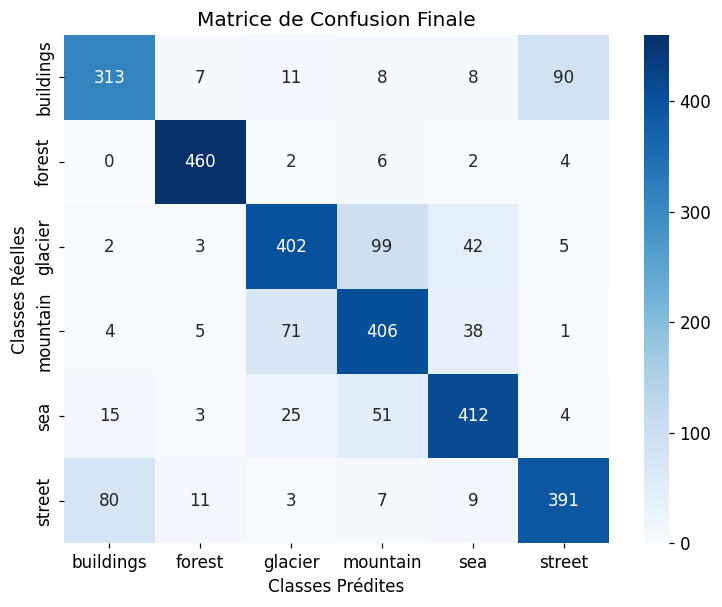


=== RAPPORT DE CLASSIFICATION ===
              precision    recall  f1-score   support

   buildings       0.76      0.72      0.74       437
      forest       0.94      0.97      0.96       474
     glacier       0.78      0.73      0.75       553
    mountain       0.70      0.77      0.74       525
         sea       0.81      0.81      0.81       510
      street       0.79      0.78      0.79       501

    accuracy                           0.79      3000
   macro avg       0.80      0.80      0.80      3000
weighted avg       0.80      0.79      0.79      3000



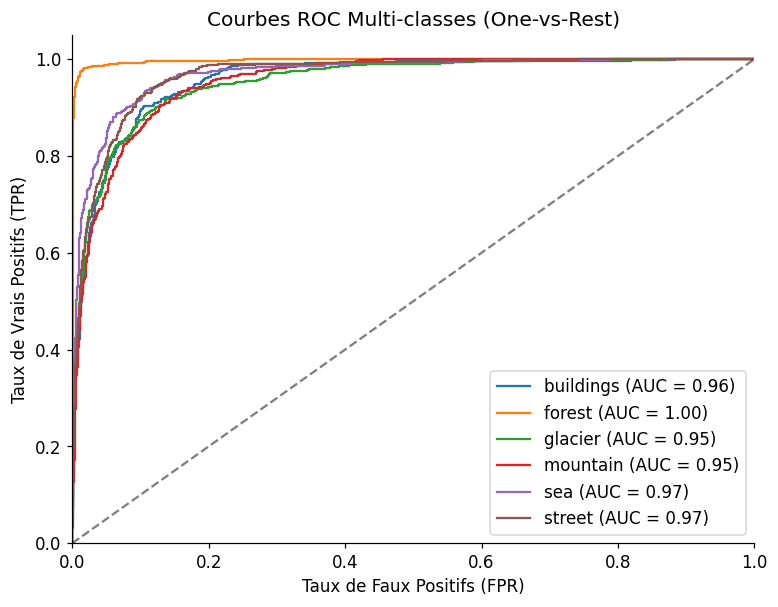

In [63]:
# -------------------------------------------------------------
# EXPÉRIENCE 1 : Entraînement du CNN Simple
# -------------------------------------------------------------
print("=== LANCEMENT DE L'ENTRAÎNEMENT : BASELINE CNN ===")
baseline_net = SimpleCNN(num_classes=len(classes))
lit_baseline = LitIntelClassifier(baseline_net, num_classes=len(classes), lr=1e-3)

# Entraînement (pensez à augmenter max_epochs selon vos besoins, ex: 15 ou 20)
trainer_baseline = train_model(lit_baseline, "Simple_CNN_Experiment", train_loader, test_loader, max_epochs=5)

# Évaluation quantitative et graphique
evaluate_and_interpret(lit_baseline, test_loader, classes)

Epoch 4/4  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439/439 0:00:55 • 0:00:00 8.03it/s v_num: 0.000 val_loss: 0.338      
                                                                                 val_acc: 0.877 train_loss: 0.417  
                                                                                 train_acc: 0.848                  

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


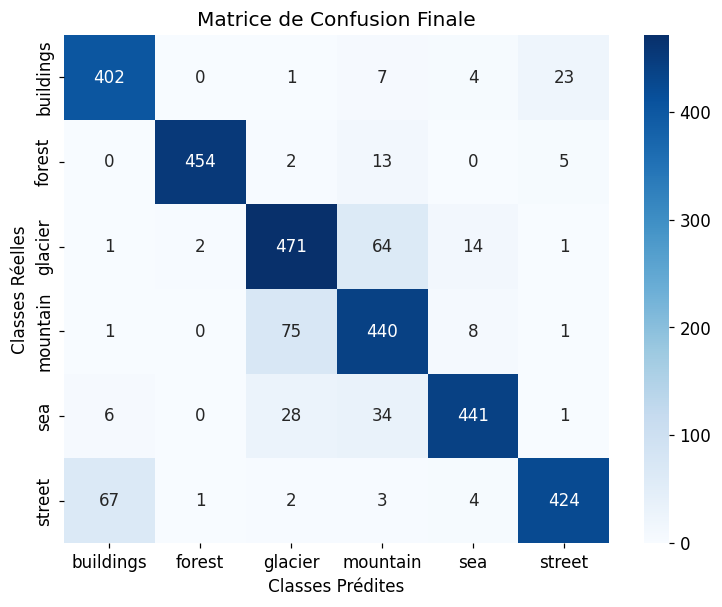


=== RAPPORT DE CLASSIFICATION ===
              precision    recall  f1-score   support

   buildings       0.84      0.92      0.88       437
      forest       0.99      0.96      0.98       474
     glacier       0.81      0.85      0.83       553
    mountain       0.78      0.84      0.81       525
         sea       0.94      0.86      0.90       510
      street       0.93      0.85      0.89       501

    accuracy                           0.88      3000
   macro avg       0.88      0.88      0.88      3000
weighted avg       0.88      0.88      0.88      3000



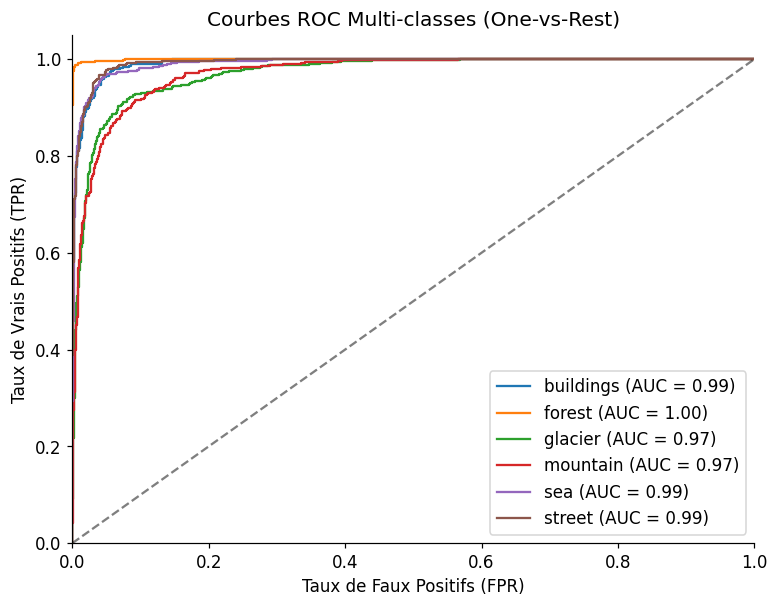

In [64]:
# -------------------------------------------------------------
# EXPÉRIENCE 2 : Transfer Learning avec ResNet18
# -------------------------------------------------------------
print("\n=== LANCEMENT DE L'ENTRAÎNEMENT : RESNET18 (TRANSFER LEARNING) ===")
resnet_net = ResNetTransfer(num_classes=len(classes), freeze_backbone=True)
lit_resnet = LitIntelClassifier(resnet_net, num_classes=len(classes), lr=1e-3)

trainer_resnet = train_model(lit_resnet, "ResNet_Transfer_Experiment", train_loader, test_loader, max_epochs=5)

# Évaluation quantitative et graphique du modèle ResNet
evaluate_and_interpret(lit_resnet, test_loader, classes)

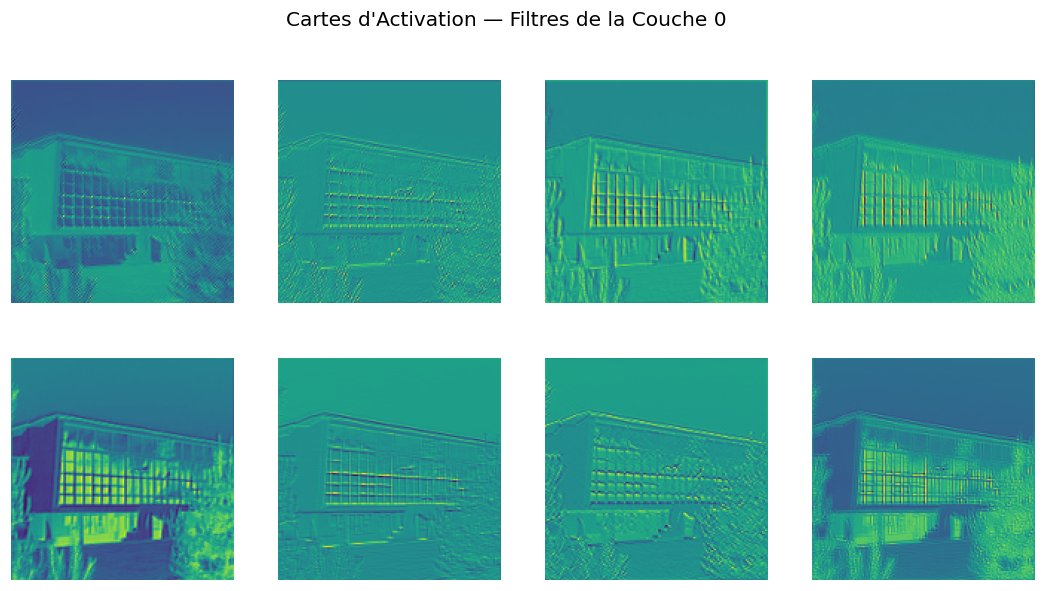

In [65]:
# Visualisation des cartes d'activation du SimpleCNN sur un échantillon d'image
sample_img, _ = test_set[0]
plot_feature_maps(baseline_net, sample_img, layer_index=0)